In [1]:
"""
SCAR Wrong Distribution Comparison Notebook
Compares correct SCAR similarity distributions with "wrong" distributions created by randomly shuffling sources to targets.
This helps verify and determine appropriate similarity thresholds.
"""

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
from sentence_transformers import SentenceTransformer
import os
import sys

# Get the notebook's directory and add parent directory to path for config import
# Notebook is in: LLM/analysis/
# Config is in: LLM/core/config.py
# Try to find the LLM directory by looking for the analysis folder or core/config.py
current_dir = os.getcwd()
llm_dir = None

# Strategy 1: Check if we're already in the LLM directory
if os.path.exists(os.path.join(current_dir, 'core', 'config.py')):
    llm_dir = current_dir
# Strategy 2: Check if we're in the analysis subdirectory
elif os.path.basename(current_dir) == 'analysis' and os.path.exists(os.path.join(os.path.dirname(current_dir), 'core', 'config.py')):
    llm_dir = os.path.dirname(current_dir)
# Strategy 3: Walk up the directory tree to find LLM directory
else:
    search_dir = os.path.abspath(current_dir)
    while search_dir:
        if os.path.exists(os.path.join(search_dir, 'core', 'config.py')):
            llm_dir = search_dir
            break
        parent = os.path.dirname(search_dir)
        if parent == search_dir:  # Reached filesystem root
            break
        search_dir = parent

if llm_dir:
    sys.path.insert(0, llm_dir)
    notebook_dir = llm_dir  # Use for env path resolution
else:
    # Last resort: assume we're in analysis folder relative to LLM
    notebook_dir = os.path.join(os.path.dirname(current_dir) if os.path.basename(current_dir) == 'analysis' else current_dir)
    if os.path.basename(notebook_dir) != 'LLM':
        # Try to construct path
        potential_llm = os.path.dirname(notebook_dir) if os.path.basename(notebook_dir) == 'analysis' else notebook_dir
        if os.path.exists(os.path.join(potential_llm, 'core', 'config.py')):
            llm_dir = potential_llm
            sys.path.insert(0, llm_dir)
            notebook_dir = llm_dir

# Load environment variables
from dotenv import load_dotenv
# Try multiple possible .env locations
env_paths = [
    os.path.join(os.path.dirname(notebook_dir), '.env'),  # LLM/.env
    os.path.join(os.path.dirname(os.path.dirname(notebook_dir)), '.env'),  # stage_2_Modular_solution/.env
    os.path.join(notebook_dir, '.env'),  # analysis/.env
]
for env_path in env_paths:
    if os.path.exists(env_path):
        load_dotenv(env_path)
        break

# Import from core.config (config is now in core/ subdirectory)
from core.config import RESULTS_DIR, EMBEDDINGS_PATH, EMBEDDING_MODEL, SCAR_PATH, SIMILARITY_THRESHOLD

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Set random seed for reproducibility
np.random.seed(42)

print("Imports completed successfully!")
print(f"Embedding model: {EMBEDDING_MODEL}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Random seed set to 42 for reproducibility")

c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports completed successfully!
Embedding model: all-MiniLM-L6-v2
Results directory: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\stage_2_Modular_solution\LLM\results
Random seed set to 42 for reproducibility


In [2]:
# Load SCAR dataset and initialize embedder
print("=" * 70)
print("Loading SCAR Dataset and Initializing Embedder")
print("=" * 70)

# Load SCAR dataset
print(f"\nLoading SCAR dataset from: {SCAR_PATH}")
scar_df = pd.read_csv(SCAR_PATH)
print(f"Loaded {len(scar_df)} target-source pairs")
print(f"Dataset columns: {scar_df.columns.tolist()}")

# Initialize SentenceTransformer embedder
print(f"\nInitializing SentenceTransformer embedder: {EMBEDDING_MODEL}")
embedder = SentenceTransformer(EMBEDDING_MODEL)
print("Embedder ready!")

# Create output directory for visualizations
output_dir = os.path.join(RESULTS_DIR, 'similarity_analysis')
os.makedirs(output_dir, exist_ok=True)
print(f"\nOutput directory: {output_dir}")

Loading SCAR Dataset and Initializing Embedder

Loading SCAR dataset from: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\stage_2_Modular_solution\LLM\..\..\data\SCAR_cleaned_manually.csv
Loaded 400 target-source pairs
Dataset columns: ['id', 'system_a', 'system_b', 'system_a_domain', 'system_b_domain', 'system_a_background', 'system_b_background', 'mappings_parsed', 'mapping_count', 'explanation_parsed', 'explanation_count', 'system_a_bg_wc', 'system_b_bg_wc']

Initializing SentenceTransformer embedder: all-MiniLM-L6-v2
Embedder ready!

Output directory: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\stage_2_Modular_solution\LLM\results\similarity_analysis


## Step 1: Compute Correct SCAR Target-Source Similarity (Average Method)

Compute target-source similarity using the average method: for each target, average the similarity of all its sources, then average all target-level averages.

In [3]:
# Compute correct SCAR target-source similarity (average method)
print("=" * 70)
print("SCAR Dataset: Target-Source Similarity (Average Method)")
print("=" * 70)
print("\nMethod: For each target, average the similarity of all its sources,")
print("        then average all target-level averages.")

# Group by target
target_groups = scar_df.groupby('system_a')['system_b'].apply(list).reset_index()
target_groups.columns = ['target', 'sources']

target_avg_similarities = []

for idx, row in target_groups.iterrows():
    target = str(row['target']).strip()
    sources = [str(s).strip() for s in row['sources'] if str(s).strip() and str(s) != 'nan']
    
    if not target or target == 'nan' or len(sources) == 0:
        continue
    
    # Compute similarity for each source of this target
    target_similarities = []
    for source in sources:
        try:
            target_emb = embedder.encode([target.lower()])[0]
            source_emb = embedder.encode([source.lower()])[0]
            
            similarity = np.dot(target_emb, source_emb) / (
                np.linalg.norm(target_emb) * np.linalg.norm(source_emb) + 1e-8
            )
            target_similarities.append(float(similarity))
        except Exception as e:
            print(f"Error processing {target} vs {source}: {e}")
            continue
    
    if len(target_similarities) > 0:
        # Average similarities for this target
        avg_sim = np.mean(target_similarities)
        target_avg_similarities.append({
            'target': target,
            'avg_similarity': avg_sim,
            'num_sources': len(target_similarities)
        })
    
    if (idx + 1) % 50 == 0:
        print(f"  Processed {idx + 1}/{len(target_groups)} targets...")

scar_sim_df_recalculated = pd.DataFrame(target_avg_similarities)
print(f"\nComputed average similarities for {len(scar_sim_df_recalculated)} targets")

# Statistics
print("\n" + "=" * 70)
print("Correct SCAR Target-Source Similarity Statistics")
print("=" * 70)
print(f"Total targets: {len(scar_sim_df_recalculated)}")
print(f"Mean of target averages: {scar_sim_df_recalculated['avg_similarity'].mean():.4f}")
print(f"Median of target averages: {scar_sim_df_recalculated['avg_similarity'].median():.4f}")
print(f"Std deviation: {scar_sim_df_recalculated['avg_similarity'].std():.4f}")
print(f"Min target average: {scar_sim_df_recalculated['avg_similarity'].min():.4f}")
print(f"Max target average: {scar_sim_df_recalculated['avg_similarity'].max():.4f}")

SCAR Dataset: Target-Source Similarity (Average Method)

Method: For each target, average the similarity of all its sources,
        then average all target-level averages.
  Processed 50/321 targets...
  Processed 100/321 targets...
  Processed 150/321 targets...
  Processed 200/321 targets...
  Processed 250/321 targets...
  Processed 300/321 targets...

Computed average similarities for 321 targets

Correct SCAR Target-Source Similarity Statistics
Total targets: 321
Mean of target averages: 0.3057
Median of target averages: 0.2715
Std deviation: 0.1732
Min target average: -0.0151
Max target average: 1.0000


## Step 2: Compute Correct SCAR Source-to-Source Similarity

Compute source-to-source similarity for targets with multiple sources (simulates generated analogy vs gold source scenario).

In [4]:
# Compute correct SCAR source-to-source similarity
print("=" * 70)
print("SCAR Dataset: Source-to-Source Similarity")
print("=" * 70)

# Find targets with multiple sources
multi_source_targets = target_groups[target_groups['sources'].apply(lambda x: len([s for s in x if str(s).strip() and str(s) != 'nan']) >= 2)]
print(f"\nFound {len(multi_source_targets)} targets with multiple sources")

# Compute source-to-source similarity
print(f"\nComputing source-to-source similarity using {EMBEDDING_MODEL}...")
source_to_source_similarities = []

for idx, row in multi_source_targets.iterrows():
    target = row['target']
    sources = [str(s).strip() for s in row['sources'] if str(s).strip() and str(s) != 'nan']
    
    if len(sources) < 2:
        continue
    
    # Compute pairwise similarity between all sources for this target
    for i, source1 in enumerate(sources):
        for j, source2 in enumerate(sources):
            if i < j:  # Only compute each pair once
                try:
                    # Compute similarity using all-MiniLM-L6-v2
                    source1_emb = embedder.encode([source1.lower()])[0]
                    source2_emb = embedder.encode([source2.lower()])[0]
                    
                    similarity = np.dot(source1_emb, source2_emb) / (
                        np.linalg.norm(source1_emb) * np.linalg.norm(source2_emb) + 1e-8
                    )
                    
                    source_to_source_similarities.append({
                        'target': target,
                        'source1': source1,
                        'source2': source2,
                        'similarity': float(similarity),
                        'num_sources_for_target': len(sources)
                    })
                except Exception as e:
                    print(f"Error processing {target}: {e}")
                    continue
    
    if (idx + 1) % 50 == 0:
        print(f"  Processed {idx + 1}/{len(multi_source_targets)} targets...")

source_sim_df = pd.DataFrame(source_to_source_similarities)
print(f"\nComputed {len(source_sim_df)} source-to-source similarity pairs")

# Statistics
print("\n" + "=" * 70)
print("Correct SCAR Source-to-Source Similarity Statistics")
print("=" * 70)
print(f"Total source pairs: {len(source_sim_df)}")
print(f"Mean similarity: {source_sim_df['similarity'].mean():.4f}")
print(f"Median similarity: {source_sim_df['similarity'].median():.4f}")
print(f"Std deviation: {source_sim_df['similarity'].std():.4f}")
print(f"Min similarity: {source_sim_df['similarity'].min():.4f}")
print(f"Max similarity: {source_sim_df['similarity'].max():.4f}")

SCAR Dataset: Source-to-Source Similarity

Found 55 targets with multiple sources

Computing source-to-source similarity using all-MiniLM-L6-v2...

Computed 145 source-to-source similarity pairs

Correct SCAR Source-to-Source Similarity Statistics
Total source pairs: 145
Mean similarity: 0.3685
Median similarity: 0.3226
Std deviation: 0.2255
Min similarity: 0.0078
Max similarity: 1.0000


In [5]:
# Create wrong SCAR distribution by shuffling sources
print("=" * 70)
print("Creating Wrong SCAR Distribution (Shuffled Sources)")
print("=" * 70)

# Get all unique sources
all_sources = scar_df['system_b'].dropna().unique().tolist()
all_sources = [str(s).strip() for s in all_sources if str(s).strip() and str(s) != 'nan']
print(f"\nTotal unique sources in dataset: {len(all_sources)}")

# Create wrong pairs: for each target, assign random sources (not the actual ones)
wrong_pairs = []

for idx, row in target_groups.iterrows():
    target = str(row['target']).strip()
    actual_sources = [str(s).strip() for s in row['sources'] if str(s).strip() and str(s) != 'nan']
    num_sources = len(actual_sources)
    
    if not target or target == 'nan' or num_sources == 0:
        continue
    
    # Get available sources (exclude actual sources for this target)
    available_sources = [s for s in all_sources if s not in actual_sources]
    
    # If we don't have enough available sources, use all sources (including actual ones)
    if len(available_sources) < num_sources:
        available_sources = all_sources.copy()
    
    # Randomly sample wrong sources
    wrong_sources = np.random.choice(available_sources, size=min(num_sources, len(available_sources)), replace=False).tolist()
    
    # Create pairs
    for source in wrong_sources:
        wrong_pairs.append({
            'target': target,
            'source': source
        })

wrong_scar_df = pd.DataFrame(wrong_pairs)
print(f"\nCreated {len(wrong_pairs)} wrong target-source pairs")
print(f"Number of unique targets in wrong distribution: {wrong_scar_df['target'].nunique()}")
print(f"Number of unique sources in wrong distribution: {wrong_scar_df['source'].nunique()}")

# Group wrong pairs by target (for average method computation)
wrong_target_groups = wrong_scar_df.groupby('target')['source'].apply(list).reset_index()
wrong_target_groups.columns = ['target', 'sources']
print(f"\nGrouped into {len(wrong_target_groups)} target groups")

Creating Wrong SCAR Distribution (Shuffled Sources)

Total unique sources in dataset: 333

Created 400 wrong target-source pairs
Number of unique targets in wrong distribution: 321
Number of unique sources in wrong distribution: 232

Grouped into 321 target groups


## Step 4: Compute Wrong Target-Source Similarity (Average Method)

Compute wrong target-source similarity using the same average method as the correct distribution.

In [6]:
# Compute wrong target-source similarity (average method)
print("=" * 70)
print("Wrong SCAR: Target-Source Similarity (Average Method)")
print("=" * 70)

wrong_target_avg_similarities = []

for idx, row in wrong_target_groups.iterrows():
    target = str(row['target']).strip()
    sources = [str(s).strip() for s in row['sources'] if str(s).strip() and str(s) != 'nan']
    
    if not target or target == 'nan' or len(sources) == 0:
        continue
    
    # Compute similarity for each wrong source of this target
    target_similarities = []
    for source in sources:
        try:
            target_emb = embedder.encode([target.lower()])[0]
            source_emb = embedder.encode([source.lower()])[0]
            
            similarity = np.dot(target_emb, source_emb) / (
                np.linalg.norm(target_emb) * np.linalg.norm(source_emb) + 1e-8
            )
            target_similarities.append(float(similarity))
        except Exception as e:
            print(f"Error processing {target} vs {source}: {e}")
            continue
    
    if len(target_similarities) > 0:
        # Average similarities for this target
        avg_sim = np.mean(target_similarities)
        wrong_target_avg_similarities.append({
            'target': target,
            'avg_similarity': avg_sim,
            'num_sources': len(target_similarities)
        })
    
    if (idx + 1) % 50 == 0:
        print(f"  Processed {idx + 1}/{len(wrong_target_groups)} targets...")

wrong_sim_df_recalculated = pd.DataFrame(wrong_target_avg_similarities)
print(f"\nComputed average similarities for {len(wrong_sim_df_recalculated)} targets")

# Statistics
print("\n" + "=" * 70)
print("Wrong SCAR Target-Source Similarity Statistics")
print("=" * 70)
print(f"Total targets: {len(wrong_sim_df_recalculated)}")
print(f"Mean of target averages: {wrong_sim_df_recalculated['avg_similarity'].mean():.4f}")
print(f"Median of target averages: {wrong_sim_df_recalculated['avg_similarity'].median():.4f}")
print(f"Std deviation: {wrong_sim_df_recalculated['avg_similarity'].std():.4f}")
print(f"Min target average: {wrong_sim_df_recalculated['avg_similarity'].min():.4f}")
print(f"Max target average: {wrong_sim_df_recalculated['avg_similarity'].max():.4f}")

Wrong SCAR: Target-Source Similarity (Average Method)
  Processed 50/321 targets...
  Processed 100/321 targets...
  Processed 150/321 targets...
  Processed 200/321 targets...
  Processed 250/321 targets...
  Processed 300/321 targets...

Computed average similarities for 321 targets

Wrong SCAR Target-Source Similarity Statistics
Total targets: 321
Mean of target averages: 0.1466
Median of target averages: 0.1375
Std deviation: 0.0988
Min target average: -0.0657
Max target average: 0.4881


## Step 5: Compute Wrong Source-to-Source Similarity

Compute source-to-source similarity for wrong pairs (targets with multiple wrong sources).

In [7]:
# Compute wrong source-to-source similarity
print("=" * 70)
print("Wrong SCAR: Source-to-Source Similarity")
print("=" * 70)

# Find targets with multiple wrong sources
wrong_multi_source_targets = wrong_target_groups[wrong_target_groups['sources'].apply(lambda x: len([s for s in x if str(s).strip() and str(s) != 'nan']) >= 2)]
print(f"\nFound {len(wrong_multi_source_targets)} targets with multiple wrong sources")

# Compute source-to-source similarity
print(f"\nComputing wrong source-to-source similarity using {EMBEDDING_MODEL}...")
wrong_source_to_source_similarities = []

for idx, row in wrong_multi_source_targets.iterrows():
    target = row['target']
    sources = [str(s).strip() for s in row['sources'] if str(s).strip() and str(s) != 'nan']
    
    if len(sources) < 2:
        continue
    
    # Compute pairwise similarity between all wrong sources for this target
    for i, source1 in enumerate(sources):
        for j, source2 in enumerate(sources):
            if i < j:  # Only compute each pair once
                try:
                    # Compute similarity using all-MiniLM-L6-v2
                    source1_emb = embedder.encode([source1.lower()])[0]
                    source2_emb = embedder.encode([source2.lower()])[0]
                    
                    similarity = np.dot(source1_emb, source2_emb) / (
                        np.linalg.norm(source1_emb) * np.linalg.norm(source2_emb) + 1e-8
                    )
                    
                    wrong_source_to_source_similarities.append({
                        'target': target,
                        'source1': source1,
                        'source2': source2,
                        'similarity': float(similarity),
                        'num_sources_for_target': len(sources)
                    })
                except Exception as e:
                    print(f"Error processing {target}: {e}")
                    continue
    
    if (idx + 1) % 50 == 0:
        print(f"  Processed {idx + 1}/{len(wrong_multi_source_targets)} targets...")

wrong_source_sim_df = pd.DataFrame(wrong_source_to_source_similarities)
print(f"\nComputed {len(wrong_source_sim_df)} wrong source-to-source similarity pairs")

# Statistics
print("\n" + "=" * 70)
print("Wrong SCAR Source-to-Source Similarity Statistics")
print("=" * 70)
print(f"Total source pairs: {len(wrong_source_sim_df)}")
print(f"Mean similarity: {wrong_source_sim_df['similarity'].mean():.4f}")
print(f"Median similarity: {wrong_source_sim_df['similarity'].median():.4f}")
print(f"Std deviation: {wrong_source_sim_df['similarity'].std():.4f}")
print(f"Min similarity: {wrong_source_sim_df['similarity'].min():.4f}")
print(f"Max similarity: {wrong_source_sim_df['similarity'].max():.4f}")

Wrong SCAR: Source-to-Source Similarity

Found 55 targets with multiple wrong sources

Computing wrong source-to-source similarity using all-MiniLM-L6-v2...

Computed 145 wrong source-to-source similarity pairs

Wrong SCAR Source-to-Source Similarity Statistics
Total source pairs: 145
Mean similarity: 0.1795
Median similarity: 0.1737
Std deviation: 0.1147
Min similarity: -0.0798
Max similarity: 0.5781


## Step 6: Visualization - Target-Source Comparison

Compare correct vs wrong target-source similarity distributions (average method).

Saved: scar_vs_wrong_target_source_comparison.png


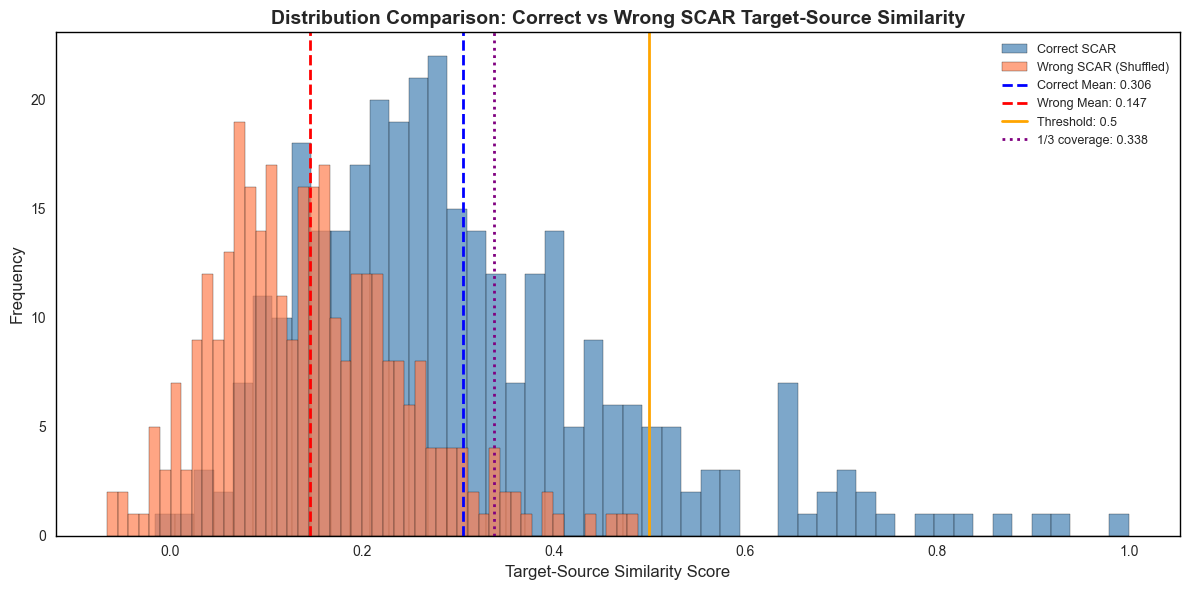

In [12]:
# Visualization: Target-Source Comparison (Average Method)
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')  # Set figure background to white
ax.set_facecolor('white')  # Set axes background to white

# Plot both histograms
ax.hist(scar_sim_df_recalculated['avg_similarity'], bins=50, alpha=0.7, edgecolor='black', color='steelblue', 
        label='Correct SCAR')
ax.hist(wrong_sim_df_recalculated['avg_similarity'], bins=50, alpha=0.7, edgecolor='black', color='coral', 
        label='Wrong SCAR (Shuffled)')

# Add mean lines
ax.axvline(scar_sim_df_recalculated['avg_similarity'].mean(), color='blue', linestyle='--', linewidth=2, 
          label=f'Correct Mean: {scar_sim_df_recalculated["avg_similarity"].mean():.3f}')
ax.axvline(wrong_sim_df_recalculated['avg_similarity'].mean(), color='red', linestyle='--', linewidth=2, 
          label=f'Wrong Mean: {wrong_sim_df_recalculated["avg_similarity"].mean():.3f}')

# # Add median lines
# ax.axvline(scar_sim_df_recalculated['avg_similarity'].median(), color='blue', linestyle=':', linewidth=1.5, 
#           label=f'Correct Median: {scar_sim_df_recalculated["avg_similarity"].median():.3f}')
# ax.axvline(wrong_sim_df_recalculated['avg_similarity'].median(), color='red', linestyle=':', linewidth=1.5, 
#           label=f'Wrong Median: {wrong_sim_df_recalculated["avg_similarity"].median():.3f}')

# Add current threshold line
ax.axvline(SIMILARITY_THRESHOLD, color='orange', linestyle='-', linewidth=2, 
          label=f'Threshold: {SIMILARITY_THRESHOLD}')

# Add 33.33% coverage threshold for correct
threshold_33_correct = scar_sim_df_recalculated['avg_similarity'].quantile(0.6667)
ax.axvline(threshold_33_correct, color='purple', linestyle=':', linewidth=2, 
          label=f'1/3 coverage: {threshold_33_correct:.3f}')

# Set axis spines (lines) to black
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['top'].set_linewidth(1)
ax.spines['right'].set_linewidth(1)

ax.set_xlabel('Target-Source Similarity Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution Comparison: Correct vs Wrong SCAR Target-Source Similarity', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
# No grid

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scar_vs_wrong_target_source_comparison.png'), 
           dpi=300, bbox_inches='tight', facecolor='white')
print("Saved: scar_vs_wrong_target_source_comparison.png")
plt.show()

## Step 7: Visualization - Source-to-Source Comparison

Compare correct vs wrong source-to-source similarity distributions.

Saved: scar_vs_wrong_source_to_source_comparison.png


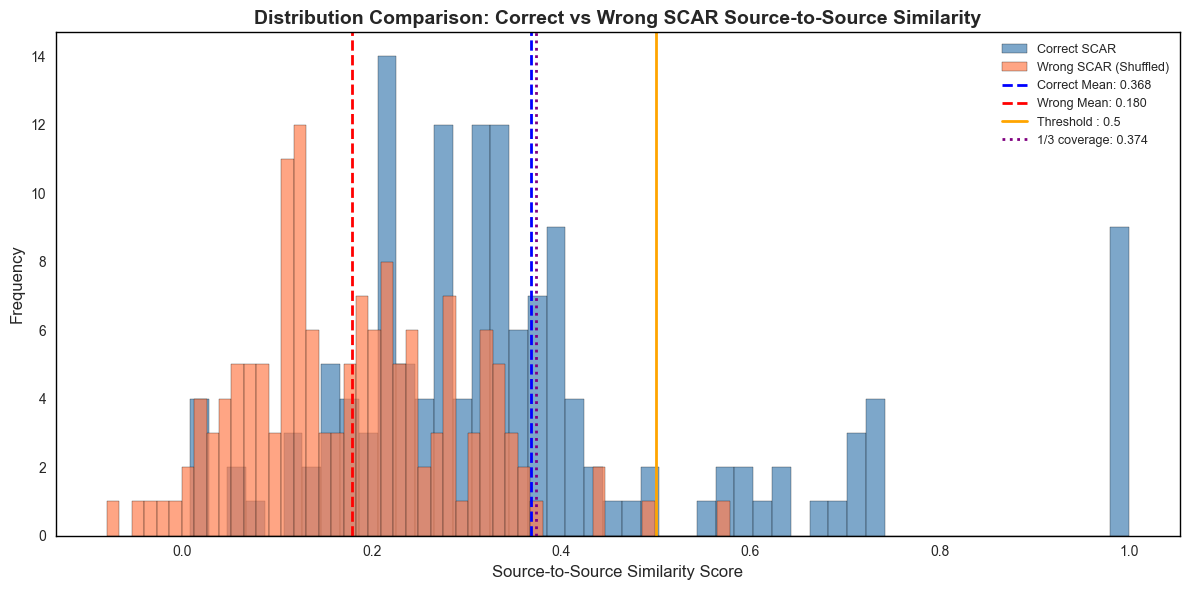

In [13]:
# Visualization: Source-to-Source Comparison
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')  # Set figure background to white
ax.set_facecolor('white')  # Set axes background to white

# Plot both histograms
ax.hist(source_sim_df['similarity'], bins=50, alpha=0.7, edgecolor='black', color='steelblue', 
        label='Correct SCAR')
ax.hist(wrong_source_sim_df['similarity'], bins=50, alpha=0.7, edgecolor='black', color='coral', 
        label='Wrong SCAR (Shuffled)')

# Add mean lines
ax.axvline(source_sim_df['similarity'].mean(), color='blue', linestyle='--', linewidth=2, 
          label=f'Correct Mean: {source_sim_df["similarity"].mean():.3f}')
ax.axvline(wrong_source_sim_df['similarity'].mean(), color='red', linestyle='--', linewidth=2, 
          label=f'Wrong Mean: {wrong_source_sim_df["similarity"].mean():.3f}')

# # Add median lines
# ax.axvline(source_sim_df['similarity'].median(), color='blue', linestyle=':', linewidth=1.5, 
#           label=f'Correct Median: {source_sim_df["similarity"].median():.3f}')
# ax.axvline(wrong_source_sim_df['similarity'].median(), color='red', linestyle=':', linewidth=1.5, 
#           label=f'Wrong Median: {wrong_source_sim_df["similarity"].median():.3f}')

# Add current threshold line
ax.axvline(SIMILARITY_THRESHOLD, color='orange', linestyle='-', linewidth=2, 
          label=f'Threshold : {SIMILARITY_THRESHOLD}')

# Add 33.33% coverage threshold for correct
threshold_33_source_correct = source_sim_df['similarity'].quantile(0.6667)
ax.axvline(threshold_33_source_correct, color='purple', linestyle=':', linewidth=2, 
          label=f'1/3 coverage: {threshold_33_source_correct:.3f}')

# Set axis spines (lines) to black
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['top'].set_linewidth(1)
ax.spines['right'].set_linewidth(1)

ax.set_xlabel('Source-to-Source Similarity Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution Comparison: Correct vs Wrong SCAR Source-to-Source Similarity', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
# No grid

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scar_vs_wrong_source_to_source_comparison.png'), 
           dpi=300, bbox_inches='tight', facecolor='white')
print("Saved: scar_vs_wrong_source_to_source_comparison.png")
plt.show()

## Step 8: Statistics Comparison

Compare statistics between correct and wrong distributions to understand the differences.

In [10]:
# Statistics Comparison
print("=" * 70)
print("COMPREHENSIVE STATISTICS COMPARISON")
print("=" * 70)

# Target-Source Similarity Comparison
print("\n" + "=" * 70)
print("TARGET-SOURCE SIMILARITY (Average Method) - Comparison")
print("=" * 70)

print("\nCorrect SCAR:")
print(f"  Mean: {scar_sim_df_recalculated['avg_similarity'].mean():.4f}")
print(f"  Median: {scar_sim_df_recalculated['avg_similarity'].median():.4f}")
print(f"  Std Dev: {scar_sim_df_recalculated['avg_similarity'].std():.4f}")
print(f"  Min: {scar_sim_df_recalculated['avg_similarity'].min():.4f}")
print(f"  Max: {scar_sim_df_recalculated['avg_similarity'].max():.4f}")
above_threshold_correct_ts = (scar_sim_df_recalculated['avg_similarity'] >= SIMILARITY_THRESHOLD).sum()
pct_above_correct_ts = (above_threshold_correct_ts / len(scar_sim_df_recalculated)) * 100
print(f"  Above threshold {SIMILARITY_THRESHOLD}: {above_threshold_correct_ts}/{len(scar_sim_df_recalculated)} ({pct_above_correct_ts:.2f}%)")

print("\nWrong SCAR (Shuffled):")
print(f"  Mean: {wrong_sim_df_recalculated['avg_similarity'].mean():.4f}")
print(f"  Median: {wrong_sim_df_recalculated['avg_similarity'].median():.4f}")
print(f"  Std Dev: {wrong_sim_df_recalculated['avg_similarity'].std():.4f}")
print(f"  Min: {wrong_sim_df_recalculated['avg_similarity'].min():.4f}")
print(f"  Max: {wrong_sim_df_recalculated['avg_similarity'].max():.4f}")
above_threshold_wrong_ts = (wrong_sim_df_recalculated['avg_similarity'] >= SIMILARITY_THRESHOLD).sum()
pct_above_wrong_ts = (above_threshold_wrong_ts / len(wrong_sim_df_recalculated)) * 100
print(f"  Above threshold {SIMILARITY_THRESHOLD}: {above_threshold_wrong_ts}/{len(wrong_sim_df_recalculated)} ({pct_above_wrong_ts:.2f}%)")

print("\nDifferences:")
mean_diff_ts = scar_sim_df_recalculated['avg_similarity'].mean() - wrong_sim_df_recalculated['avg_similarity'].mean()
median_diff_ts = scar_sim_df_recalculated['avg_similarity'].median() - wrong_sim_df_recalculated['avg_similarity'].median()
print(f"  Mean difference: {mean_diff_ts:.4f} (Correct - Wrong)")
print(f"  Median difference: {median_diff_ts:.4f} (Correct - Wrong)")
print(f"  Threshold coverage difference: {pct_above_correct_ts - pct_above_wrong_ts:.2f}% (Correct - Wrong)")

# Source-to-Source Similarity Comparison
print("\n" + "=" * 70)
print("SOURCE-TO-SOURCE SIMILARITY - Comparison")
print("=" * 70)

print("\nCorrect SCAR:")
print(f"  Mean: {source_sim_df['similarity'].mean():.4f}")
print(f"  Median: {source_sim_df['similarity'].median():.4f}")
print(f"  Std Dev: {source_sim_df['similarity'].std():.4f}")
print(f"  Min: {source_sim_df['similarity'].min():.4f}")
print(f"  Max: {source_sim_df['similarity'].max():.4f}")
above_threshold_correct_ss = (source_sim_df['similarity'] >= SIMILARITY_THRESHOLD).sum()
pct_above_correct_ss = (above_threshold_correct_ss / len(source_sim_df)) * 100
print(f"  Above threshold {SIMILARITY_THRESHOLD}: {above_threshold_correct_ss}/{len(source_sim_df)} ({pct_above_correct_ss:.2f}%)")

print("\nWrong SCAR (Shuffled):")
print(f"  Mean: {wrong_source_sim_df['similarity'].mean():.4f}")
print(f"  Median: {wrong_source_sim_df['similarity'].median():.4f}")
print(f"  Std Dev: {wrong_source_sim_df['similarity'].std():.4f}")
print(f"  Min: {wrong_source_sim_df['similarity'].min():.4f}")
print(f"  Max: {wrong_source_sim_df['similarity'].max():.4f}")
above_threshold_wrong_ss = (wrong_source_sim_df['similarity'] >= SIMILARITY_THRESHOLD).sum()
pct_above_wrong_ss = (above_threshold_wrong_ss / len(wrong_source_sim_df)) * 100
print(f"  Above threshold {SIMILARITY_THRESHOLD}: {above_threshold_wrong_ss}/{len(wrong_source_sim_df)} ({pct_above_wrong_ss:.2f}%)")

print("\nDifferences:")
mean_diff_ss = source_sim_df['similarity'].mean() - wrong_source_sim_df['similarity'].mean()
median_diff_ss = source_sim_df['similarity'].median() - wrong_source_sim_df['similarity'].median()
print(f"  Mean difference: {mean_diff_ss:.4f} (Correct - Wrong)")
print(f"  Median difference: {median_diff_ss:.4f} (Correct - Wrong)")
print(f"  Threshold coverage difference: {pct_above_correct_ss - pct_above_wrong_ss:.2f}% (Correct - Wrong)")

# Summary
print("\n" + "=" * 70)
print("SUMMARY & INSIGHTS")
print("=" * 70)
print(f"\nCurrent similarity threshold: {SIMILARITY_THRESHOLD}")
print(f"\nTarget-Source Similarity:")
print(f"  - Correct SCAR has {mean_diff_ts:.4f} higher mean similarity than wrong SCAR")
print(f"  - {pct_above_correct_ts:.2f}% of correct pairs vs {pct_above_wrong_ts:.2f}% of wrong pairs above threshold")
print(f"  - Threshold separates correct from wrong by {pct_above_correct_ts - pct_above_wrong_ts:.2f} percentage points")

print(f"\nSource-to-Source Similarity:")
print(f"  - Correct SCAR has {mean_diff_ss:.4f} higher mean similarity than wrong SCAR")
print(f"  - {pct_above_correct_ss:.2f}% of correct pairs vs {pct_above_wrong_ss:.2f}% of wrong pairs above threshold")
print(f"  - Threshold separates correct from wrong by {pct_above_correct_ss - pct_above_wrong_ss:.2f} percentage points")

print("\n" + "=" * 70)

COMPREHENSIVE STATISTICS COMPARISON

TARGET-SOURCE SIMILARITY (Average Method) - Comparison

Correct SCAR:
  Mean: 0.3057
  Median: 0.2715
  Std Dev: 0.1732
  Min: -0.0151
  Max: 1.0000
  Above threshold 0.5: 37/321 (11.53%)

Wrong SCAR (Shuffled):
  Mean: 0.1466
  Median: 0.1375
  Std Dev: 0.0988
  Min: -0.0657
  Max: 0.4881
  Above threshold 0.5: 0/321 (0.00%)

Differences:
  Mean difference: 0.1591 (Correct - Wrong)
  Median difference: 0.1339 (Correct - Wrong)
  Threshold coverage difference: 11.53% (Correct - Wrong)

SOURCE-TO-SOURCE SIMILARITY - Comparison

Correct SCAR:
  Mean: 0.3685
  Median: 0.3226
  Std Dev: 0.2255
  Min: 0.0078
  Max: 1.0000
  Above threshold 0.5: 27/145 (18.62%)

Wrong SCAR (Shuffled):
  Mean: 0.1795
  Median: 0.1737
  Std Dev: 0.1147
  Min: -0.0798
  Max: 0.5781
  Above threshold 0.5: 1/145 (0.69%)

Differences:
  Mean difference: 0.1889 (Correct - Wrong)
  Median difference: 0.1490 (Correct - Wrong)
  Threshold coverage difference: 17.93% (Correct - Wron